In [24]:
import h5py
import numpy as np
from astropy import units
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.colors as colors


In [2]:
data = h5py.File("TNG100-1_subhalosCat.hdf5", 'r')

In [3]:
#get data functions with correct units
def gethubble(data):
    hubble_param = data["Header"].attrs["HubbleParam"]
    return hubble_param

def getbox_size(data):
    hubble_param = gethubble(data)
    raw_box_size = data["Header"].attrs["BoxSize"]
    box_size = (raw_box_size / hubble_param) * units.kpc
    return box_size

#position of subhalo compared to periodic box. Position is of particle with minimum gravitational potential energy.
def getsubhalo_pos(data):
    hubble_param = gethubble(data)
    raw_subhalo_pos = data["Subhalo"]["SubhaloPos"]                  #is in ckpc/h
    subhalo_pos = (raw_subhalo_pos / hubble_param) * units.kpc
    return subhalo_pos

#cm of each subhalo, determined with all types of particles.
def getsubhalo_cm(data):
    hubble_param = gethubble(data)
    raw_subhalo_cm = data["Subhalo"]["SubhaloCM"]                    #is in ckpc/h
    subhalo_cm = (raw_subhalo_cm / hubble_param) * units.kpc
    return subhalo_cm

#total mass of all particles of subhalo. subhalo's of a subhalo not included in mass.
def getsubhalo_mass(data):
    hubble_param = gethubble(data)
    raw_subhalo_mass = np.array(data["Subhalo"]["SubhaloMass"])              #is in 10**10 solmass/h
    subhalo_mass = (raw_subhalo_mass*1e10/hubble_param) * units.Msun
    return subhalo_mass

#total mass of subhalo by particle type. 
def getsubhalo_massbytype(data):
    hubble_param = gethubble(data)
    raw_subhalo_massbytype = np.array(data["Subhalo"]["SubhaloMassType"])      #is in 10**10 solmass/h
    subhalo_massbytype = (raw_subhalo_massbytype*1e10/hubble_param) * units.Msun
    #Nx6, [Gas, DM, UNUSED, Tracers, Stars/wind particles, Black holes]
    return subhalo_massbytype

In [4]:
#boolean numpy array stating if a subhalo at that index contains a galaxy. 
def getgalaxy_mask(data):
    total_mass = getsubhalo_massbytype(data)
    stellar_mass = total_mass[:,4]

    mask = (stellar_mass > 0.0)
    return mask

def getgalaxy_stellar_mass(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_mass = getsubhalo_massbytype(data)
    total_subhalo_mass = getsubhalo_mass(data)
    
    total_gal_mass = total_subhalo_mass[galaxy_mask]
    
    galaxy_mass = subhalo_mass[galaxy_mask, :]
    galaxy_stellar_mass = galaxy_mass[:,4]
    
    return total_gal_mass, galaxy_stellar_mass

def getgalaxy_DM_mass(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_mass = getsubhalo_massbytype(data)
    total_subhalo_mass = getsubhalo_mass(data)
    
    total_gal_mass = total_subhalo_mass[galaxy_mask]
    
    galaxy_mass = subhalo_mass[galaxy_mask, :]
    galaxy_DM_mass = galaxy_mass[:,1]
    
    return total_gal_mass, galaxy_DM_mass

In [5]:
galaxy_mass, galaxy_stellar_mass = getgalaxy_stellar_mass(data)

In [6]:
print(galaxy_stellar_mass)

[  798953.72010629  5503566.94715087  1064621.89991143 ...
   856940.8768822   1222448.88544435 25096273.98878063] solMass


In [7]:
print(galaxy_mass)

[1.69500287e+09 1.69224390e+09 1.80722017e+09 ... 3.06858506e+08
 2.40052955e+08 2.50962740e+07] solMass


In [21]:
# Define grid
steps = 200
x_ = np.linspace(7, 15, steps)
y_ = np.linspace(5, 13, steps)
# Create empty array for potentials
counts_xy = np.zeros((len(y_), len(x_)))


dx = (x_.max() - x_.min()) / (steps - 1)
dy = (y_.max() - y_.min()) / (steps - 1)

m = np.log10(galaxy_mass / units.Msun)
s = np.log10(galaxy_stellar_mass / units.Msun)

for i, x in enumerate(x_):
    mass_mask = (m >= x) & (m < x + dx)
    for j, y in enumerate(y_):
        stel = s[mass_mask]
        counts_xy[j, i] = ((stel >= y) & (stel < y + dy)).sum()

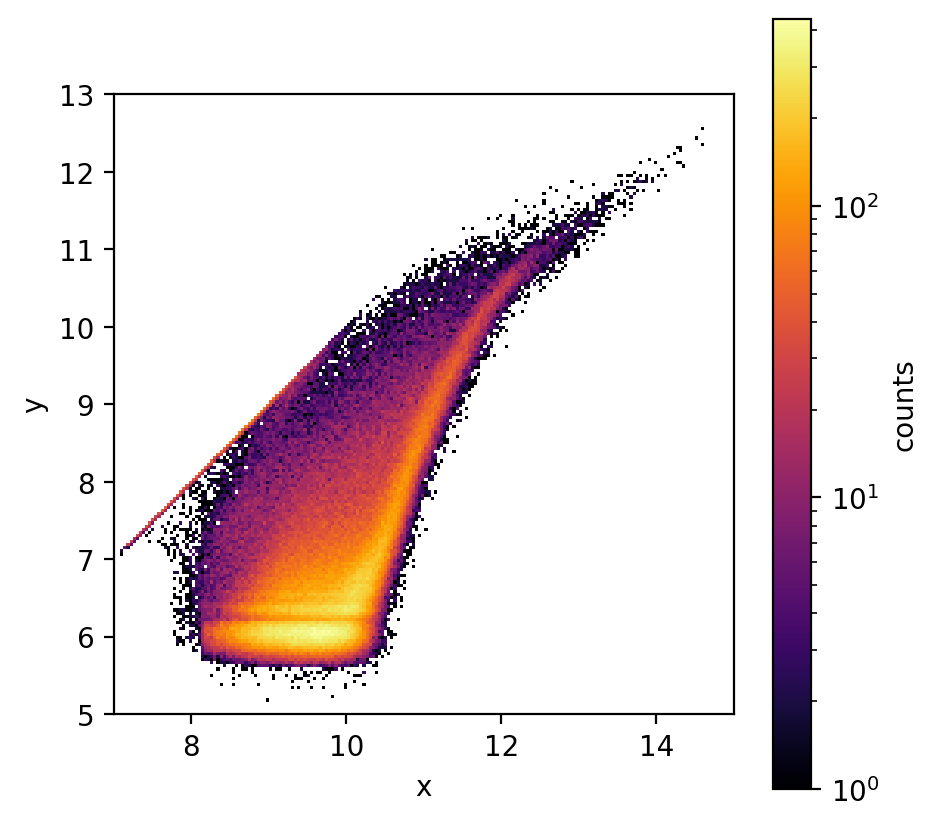

In [25]:
# Plot colormap
plt.figure(figsize=(5,5), dpi=200)
plt.imshow(counts_xy, origin='lower', extent=[7, 15, 5, 13], cmap='inferno', norm=colors.LogNorm())
plt.colorbar(label=r'counts')
plt.xlabel('x')
plt.ylabel('y')


plt.savefig('SHMR_xy')
plt.show()


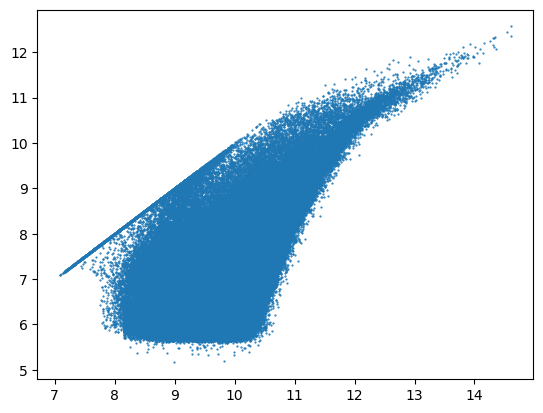

In [8]:
fig, ax = plt.subplots()
ax.scatter(np.log10(galaxy_mass / units.Msun), np.log10(galaxy_stellar_mass/units.Msun),  s = 0.3)
#ax.set_xscale('log', base=10)
#ax.set_yscale('log', base=10)

plt.show()

In [26]:
galaxy_mass, galaxy_DM_mass = getgalaxy_DM_mass(data)

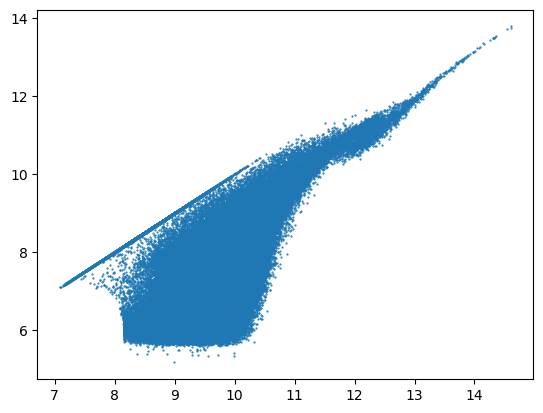

In [10]:
fig, ax = plt.subplots()
ax.scatter(np.log10(galaxy_mass / units.Msun), np.log10((galaxy_mass - galaxy_DM_mass)/units.Msun),  s = 0.3)
#ax.set_xscale('log', base=10)
#ax.set_yscale('log', base=10)

plt.show()

In [27]:
# Define grid
steps = 200
x_ = np.linspace(7, 15, steps)
y_ = np.linspace(5, 14, steps)
# Create empty array for potentials
counts_xy = np.zeros((len(y_), len(x_)))


dx = (x_.max() - x_.min()) / (steps - 1)
dy = (y_.max() - y_.min()) / (steps - 1)

m = np.log10(galaxy_mass / units.Msun)
s = np.log10((galaxy_mass - galaxy_DM_mass) / units.Msun)

for i, x in enumerate(x_):
    mass_mask = (m >= x) & (m < x + dx)
    for j, y in enumerate(y_):
        stel = s[mass_mask]
        counts_xy[j, i] = ((stel >= y) & (stel < y + dy)).sum()

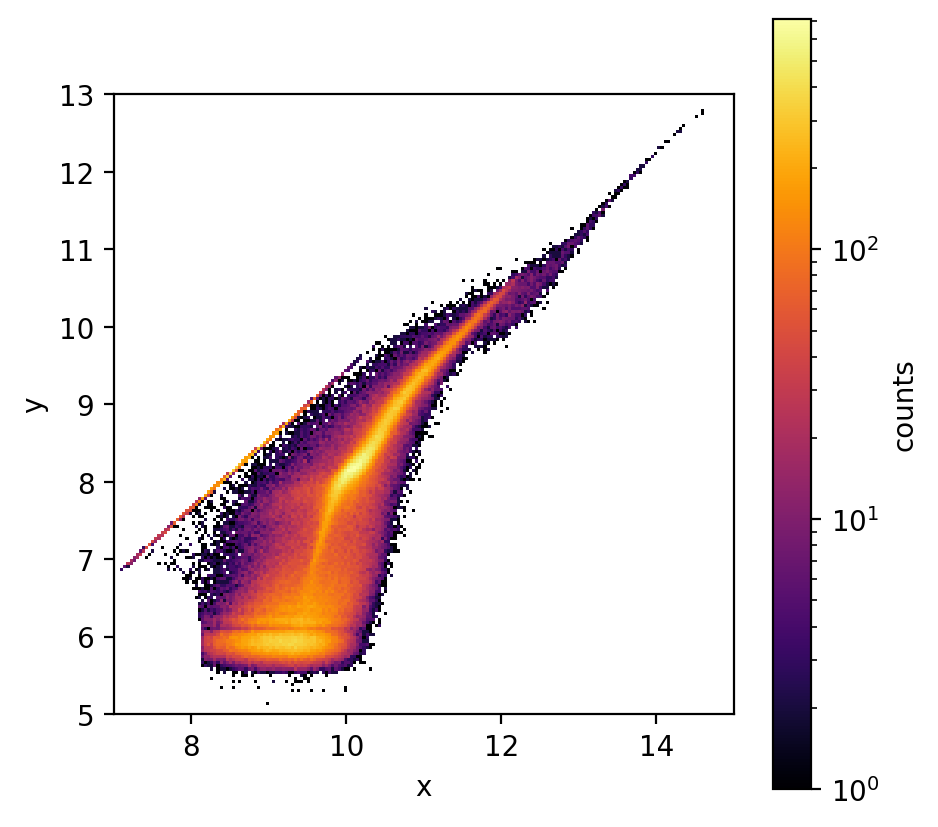

In [28]:
# Plot colormap
plt.figure(figsize=(5,5), dpi=200)
plt.imshow(counts_xy, origin='lower', extent=[7, 15, 5, 13], cmap='inferno', norm=colors.LogNorm())
plt.colorbar(label=r'counts')
plt.xlabel('x')
plt.ylabel('y')


plt.savefig('BHMR_xy')
plt.show()
